#  Handwriting number data Chapter 8 Workshop 7

## Load data

In [45]:
from tensorflow.keras.datasets.mnist import load_data
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = load_data()



## Check data dimension

In [2]:
print("x_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Check type
print("X_train type:", type(X_train))
print("y_train type:", type(y_train))

# Check the data types
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
X_train type: <class 'numpy.ndarray'>
y_train type: <class 'numpy.ndarray'>
X_train dtype: uint8
y_train dtype: uint8


## show image of X_train

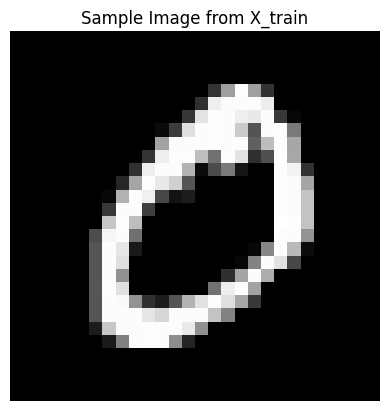

In [3]:
import matplotlib.pyplot as plt

# Display the first image in X_train
plt.imshow(X_train[1], cmap='gray')
plt.title("Sample Image from X_train")
plt.axis('off')
plt.show()

## Check label

### label data

In [4]:
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

### check min and max

In [5]:
# Minimum
print('Min value in X_train:', np.min(X_train))
# Maximum
print('Max value in X_train:', np.max(X_train))

Min value in X_train: 0
Max value in X_train: 255


## Check missing data and duplicate data

In [6]:
# Check for missing data in X_train
print("Missing data in X_train:", np.any(np.isnan(X_train)))

# Check for missing data in X_test
print("Missing data in X_test:", np.any(np.isnan(X_test)))

# Check for missing data in y_train
print("Missing data in y_train:", np.any(np.isnan(y_train)))

# Check for missing data in y_test
print("Missing data in y_test:", np.any(np.isnan(y_test)))

# Check for duplicates in X_train
duplicates_train = np.unique(X_train, axis=0, return_counts=True)
print("Duplicates in X_train:", duplicates_train[1][duplicates_train[1] > 1])

# Check for duplicates in X_test
duplicates_test = np.unique(X_test, axis=0, return_counts=True)
print("Duplicates in X_test:", duplicates_test[1][duplicates_test[1] > 1])

Missing data in X_train: False
Missing data in X_test: False
Missing data in y_train: False
Missing data in y_test: False
Duplicates in X_train: []
Duplicates in X_test: []


# Visualization Handwriting Chpater 8 Workshop 8

In [106]:

def visual_multi(initial): 
    # Plot 40 images from X_train
    plt.figure(figsize=(8, 4))
    n_plot = 40
    initial_index = 0
    for i in range(n_plot):
        plt.subplot(4, 10, i + 1)
        plt.imshow(initial_index+X_train[i], cmap=plt.cm.gray_r) # cmap='gray'
        plt.title(f"{y_train[i]}")
        # plt.axis('off')
        plt.xticks([])
        plt.yticks([])
    # plt.tight_layout()
    plt.show()

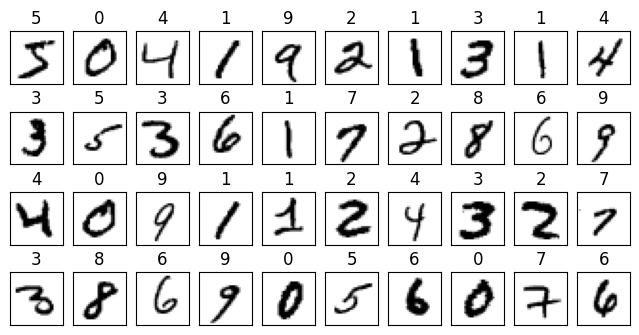

In [107]:
visual_multi(0)

In [114]:
print('X_train type:', type(X_train))
# print(X_train[0])

X_train type: <class 'numpy.ndarray'>


# Prepare train and test data Chapter 8 Workshop 9

## Prepare data construct

### Check data shape

In [46]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


### Reshape X data

In [47]:
# X_train = X_train.reshape((6000,28,28,1))
# X_test = X_test.reshape((1000,28,28,1))

# X_train = X_train.reshape((-1,28,28,1)) # -1 means the number of samples
# X_test = X_test.reshape((-1,28,28,1))   # -1 means the number of samples

# Auto reshape with out specifying the number of samples
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))

# use np.expand_dims
# X_train = np.expand_dims(X_train, axis=-1)    # -1 means add the dimension at the last axis
# X_test = np.expand_dims(X_test, axis=-1)      # -1 means add the dimension at the last axis

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## Nomalization

In [48]:
# Nomalization when data is in range 0-255
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f'Min value: {np.min(X_train)}')
print(f'Max value: {np.max(X_train)}')

Min value: 0.0
Max value: 1.0


In [49]:
X_train[0,10,10:15]

array([[0.00392157],
       [0.6039216 ],
       [0.99215686],
       [0.3529412 ],
       [0.        ]], dtype=float32)

## Specific batch size

In [50]:
number_sample = 10000
X_train = X_train[:number_sample]
y_train = y_train[:number_sample]

## Check distribution

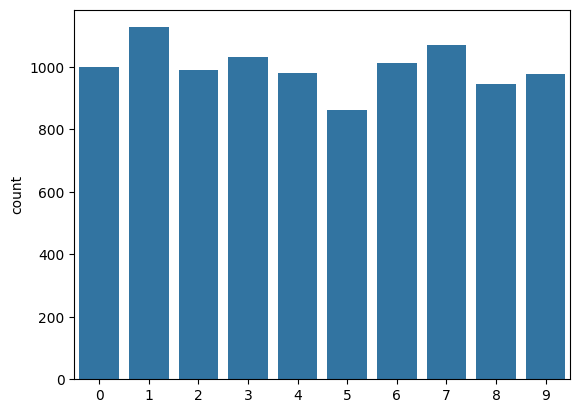

In [51]:
import warnings
warnings.filterwarnings("ignore")


import seaborn as sns

sns.countplot(x=y_train)
# plt.xlabel('Digits')
# plt.ylabel('Frequency')
# plt.title('Distribution of Digits in y_train')
# plt.show()

del sns

# Create Model Chapter 8 Workshop 10

## Check number of y_train's class

In [52]:
number_class = len(np.unique(y_train))
print("Number of classes:", number_class)

Number of classes: 10


## Define input_shape

In [53]:
in_shape = X_train.shape[1:]
print("Input shape:", in_shape)

Input shape: (28, 28, 1)


## Create model

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the model
model = Sequential()

# Add Feature Extraction Layers
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=in_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())

# Add Classification Layers
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(number_class, activation='softmax'))

# Check the model summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Plot model

In [55]:
from tensorflow.keras.utils import plot_model


# Plot the model
plot_model(model, to_file='digit.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Compile model

In [56]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Train model

In [57]:
import time

start = time.time()
model.fit(X_train, y_train, epochs=15, batch_size=128, validation_split=0.1)
end = time.time()
print(f"Training time: {round(end - start,2)} seconds")

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4340 - loss: 1.6538 - val_accuracy: 0.9220 - val_loss: 0.2608
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8937 - loss: 0.3742 - val_accuracy: 0.9480 - val_loss: 0.1540
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9237 - loss: 0.2588 - val_accuracy: 0.9620 - val_loss: 0.1149
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9425 - loss: 0.1859 - val_accuracy: 0.9720 - val_loss: 0.0925
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9493 - loss: 0.1665 - val_accuracy: 0.9800 - val_loss: 0.0778
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9570 - loss: 0.1487 - val_accuracy: 0.9790 - val_loss: 0.0807
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9616 - loss: 0.1284 - val_accuracy: 0.9810 - val_loss: 0.0712
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9648 - loss: 0.1150 - val_accuracy: 0.9820 - val_loss:

In [58]:
print('X_train type:', type(X_train))
print('X_test type:', type(X_test))

X_train type: <class 'numpy.ndarray'>
X_test type: <class 'numpy.ndarray'>


## Evaluate model

In [59]:
score = model.evaluate(X_test, y_test)

print("Test loss:", round(score[0],3))
print("Test accuracy:", round(score[1],3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0594
Test loss: 0.049
Test accuracy: 0.984


## Save model

In [60]:
# model.save('./model/handawrite_number_model.h5')
print("Model saved successfully.")

Model saved successfully.


In [63]:
print(model.get_config()['layers'][0]['config']['batch_shape'])

(None, 28, 28, 1)


# Check fail prediction Chapter 8 Workshop 11

In [16]:
# Predict the test set with one-hot vector
y_pred = model.predict(X_test)
print("Predicted shape:", y_pred.shape)
print(type(y_pred))



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted shape: (10000, 10)
<class 'numpy.ndarray'>


In [17]:
# Find the class
y_pred_cls = np.argmax(y_pred, axis=1)

print("Predicted class shape:", y_pred_cls.shape)
print("Predicted y :", y_pred[0:2])
print("Predicted class:", y_pred_cls[0:10])
print("True class:", y_test[0:10])

Predicted class shape: (10000,)
Predicted y : [[1.9427985e-08 9.0295066e-10 4.4716080e-07 9.9983038e-07 8.5413282e-12
  2.0683326e-10 1.5512768e-14 9.9999845e-01 3.0332334e-11 1.5229645e-07]
 [4.8084657e-06 4.0693514e-05 9.9995220e-01 1.5441412e-06 4.6892063e-11
  7.5781471e-11 7.1669268e-07 1.4469403e-08 1.3371644e-07 5.5192656e-10]]
Predicted class: [7 2 1 0 4 1 4 9 5 9]
True class: [7 2 1 0 4 1 4 9 5 9]


## Check fail index

In [18]:

# fail_index = [i for i in range(len(y_pred_cls)) if y_pred_cls[i] != y_test[i]]
# print("Different index:", fail_index)
# print("Different number:", len(fail_index))

inx_miss = np.where(y_pred_cls != y_test)

print("Different index:", inx_miss[0][:15])
print(y_pred_cls[inx_miss][:15])
print(y_test[inx_miss][:15])

Different index: [184 247 320 321 445 495 582 591 684 717 740 810 844 882 924]
[2 2 1 7 0 0 2 2 3 6 9 2 7 7 7]
[8 4 9 2 6 8 8 8 7 0 4 7 8 9 2]


## Visualization

In [19]:


def visual_multi_test_miss(initial, *, X_test, index_miss): 
    # Plot 40 images from X_train
    plt.figure(figsize=(8, 4))
    n_plot = 40
    initial_index = initial
    for i in range(n_plot):
        display_index = index_miss[0][initial_index + i]
        plt.subplot(4, 10, i + 1)
        plt.imshow(X_test[display_index], cmap=plt.cm.gray_r)
        plt.title(f"{y_pred_cls[display_index]}, {y_test[display_index]}")
        # plt.axis('off')
        plt.xticks([])
        plt.yticks([])
    # plt.tight_layout()
    plt.show()
    # print("True class:", y_test[index_miss][initial_index:initial_index+n_plot])

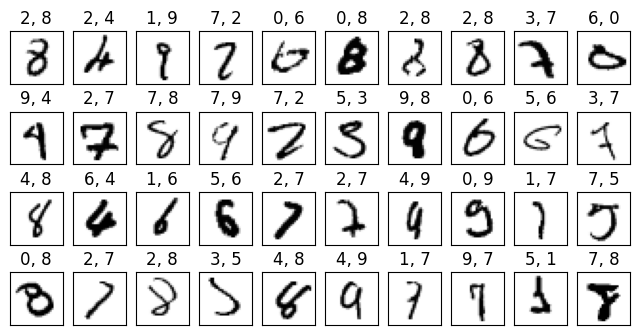

In [20]:
visual_multi_test_miss(0, X_test=X_test, index_miss=inx_miss)

# Predict model with the own handwriting Chapter 8 Workshop 12

## Predict with 1 image

### Load data

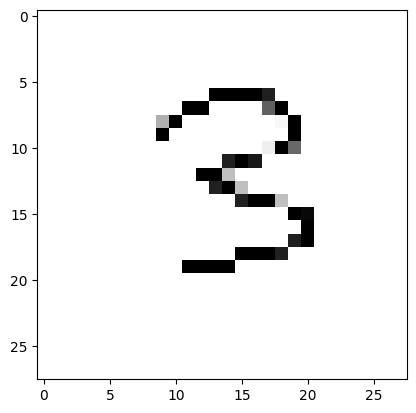

In [21]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.image import rgb_to_grayscale

# load image
img_file = './image/digit/digit3.png'
img = load_img(img_file, target_size=(28, 28))


img_g = load_img(img_file, color_mode='grayscale', target_size=(28, 28))
img_g = img_to_array(img_g)

plt.imshow(img, cmap=plt.cm.gray_r)
plt.show()

In [22]:
print('img_g type:', type(img_g))
print('img_g shape:', img_g.shape)

img_g type: <class 'numpy.ndarray'>
img_g shape: (28, 28, 1)


### Convert to grayscale

In [23]:
from PIL import Image, ImageOps

# Invert the image
img = ImageOps.invert(img)
# Convert to array  
img_arr = img_to_array(img)             # numpy array type
# Convert to rgb to grayscale
img_gray = rgb_to_grayscale(img_arr)    # class 'tensorflow.python.framework.ops.EagerTensor'



In [24]:
# Debug
print('img_gray type:', type(img_gray))
print('img_gray shape:', img_gray.shape)


img_gray type: <class 'tensorflow.python.framework.ops.EagerTensor'>
img_gray shape: (28, 28, 1)


Image shape: (28, 28, 1)
Image_g shape: (28, 28, 1)


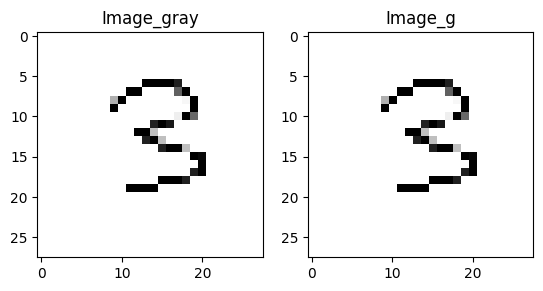

In [25]:
print("Image shape:", img_gray.shape)
print("Image_g shape:", img_g.shape)

plt.Figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap = plt.cm.gray_r)
plt.title("Image_gray")
plt.subplot(1, 2, 2)
plt.imshow(img_g, cmap = 'gray') # 
plt.title("Image_g")
plt.show()


In [26]:
print(type(img_gray))
print(type(img_g))

print('img_gray first value', img_gray[0][0][0])
print('img_g first value', img_g[0][0])

<class 'tensorflow.python.framework.ops.EagerTensor'>
<class 'numpy.ndarray'>
img_gray first value tf.Tensor(0.0, shape=(), dtype=float32)
img_g first value [255.]


### Prepare image before prediction

#### Nomalization

In [27]:
# Normalize the image
img_gray = img_gray / 255.0

print("Max value:", np.max(img_gray))
print("Min value:", np.min(img_gray))

Max value: 0.99990004
Min value: 0.0


In [28]:
# img_gray = img_gray.reshape((1, 28, 28, 1))

img_gray = np.expand_dims(img_gray,axis=0)
print("Image shape:", img_gray.shape)



Image shape: (1, 28, 28, 1)


### Predict image

In [29]:
y_pred_1 = model.predict(img_gray)

print('Predicted class:', np.argmax(y_pred_1, axis=1))
print('Predicted class:', y_pred_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted class: [3]
Predicted class: [[1.4290669e-04 3.7000373e-05 3.0713217e-02 9.4763786e-01 5.4829457e-06
  1.3690956e-02 1.9394809e-05 3.7880342e-03 6.1062124e-04 3.3545112e-03]]


## Prediction all images

### Create function

In [30]:
def predict_digits(model, img_files):
    y_preds = []; y_preds_cls = []; img_lst = []
    for img_file in img_files:
        # Load and preprocess the image
        img = load_img(img_file, target_size=(28, 28))
        
        # Convert to grayscale image
        img = ImageOps.invert(img)
        img_arr = img_to_array(img)
        img_gray = rgb_to_grayscale(img_arr)

        # Normalize the image
        img_gray = img_gray / 255.0
        # Expand dimensions to match the input shape of the model
        img_gray = np.expand_dims(img_gray, axis=0)

        # Make prediction
        y_pred = model.predict(img_gray)
        y_pred_cls = np.argmax(y_pred, axis=1)

        # Append results
        y_preds.append(y_pred)
        y_preds_cls.append(y_pred_cls)
        img_lst.append(img)

    return y_preds, y_preds_cls, img_lst

In [31]:
def predict_digits_2(model, img_files):
    y_preds = []; y_preds_cls = []; img_lst = []
    for img_file in img_files:
        # Load and preprocess the image
        img = load_img(img_file, color_mode='grayscale', target_size=(28, 28))
        
        
        img_gray = img_to_array(img)

        # Normalize the image
        img_gray = img_gray / 255.0
        # Expand dimensions to match the input shape of the model
        img_gray = np.expand_dims(img_gray, axis=0)

        # Make prediction
        y_pred = model.predict(img_gray)
        y_pred_cls = np.argmax(y_pred, axis=1)

        # Append results
        y_preds.append(y_pred)
        y_preds_cls.append(y_pred_cls)
        img_lst.append(img)

    return y_preds, y_preds_cls, img_lst

### Prepare image file lists

In [32]:
image_files = []
for i in range(10):
    image_files.append(f'./image/digit/digit{i}.png')

print(image_files)

['./image/digit/digit0.png', './image/digit/digit1.png', './image/digit/digit2.png', './image/digit/digit3.png', './image/digit/digit4.png', './image/digit/digit5.png', './image/digit/digit6.png', './image/digit/digit7.png', './image/digit/digit8.png', './image/digit/digit9.png']


### Prediction

In [33]:
y_preds,y_preds_cls, img_lis =  predict_digits(model, image_files)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 


### Show result

Classses: [0, 1, 2, 3, 4, 5, 5, 7, 2, 9]


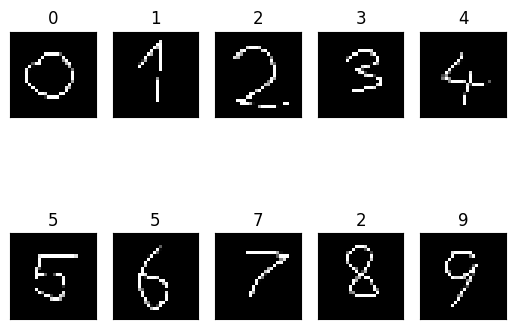

In [34]:
print('Classses:', [int(y_pred_cls[0]) for y_pred_cls in y_preds_cls])

for i in range(len(image_files)):
    plt.subplot(2, 5, i + 1)
    # plt.imshow(load_img(image_files[i], color_mode='grayscale', target_size=(28, 28)), cmap='gray')
    plt.imshow(img_lis[i])
    plt.title(f"{y_preds_cls[i][0]}")
    # plt.axis('off')
    plt.xticks([])
    plt.yticks([])

## Predict data with grayscale from loading data

### Load data with grayscale

img_g type: <class 'numpy.ndarray'>
img_g shape: (28, 28, 1)
img_g first value 255.0


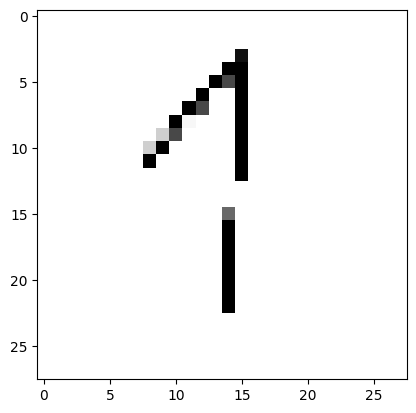

In [35]:
img_file = './image/digit/digit1.png'
img_g = load_img(img_file, color_mode='grayscale', target_size=(28, 28))

img_g = img_to_array(img_g)

print('img_g type:', type(img_g))
print('img_g shape:', img_g.shape)
print('img_g first value', img_g[0][0][0])

plt.imshow(img_g, cmap='gray')
plt.show()

### Create Invert function

In [36]:
def invert_grayscale(img_g):
    """
    Inverts a grayscale image.

    Parameters:
        img_g (numpy.ndarray): Input grayscale image as a 2D numpy array.

    Returns:
        numpy.ndarray: Inverted grayscale image.
    """
    # # Ensure the input is a valid grayscale image
    # if not isinstance(img_g, np.ndarray) or img_g.ndim != 2:
    #     raise ValueError("Input must be a 2D numpy array representing a grayscale image.")
    
    # Invert the grayscale values
    inverted_img = 255 - img_g
    return inverted_img

### Invert grayscale

img_g type: <class 'numpy.ndarray'>
img_g shape: (28, 28, 1)
img_g first value 0.0


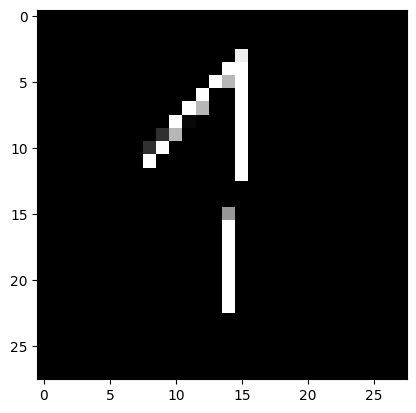

In [37]:
img_g = invert_grayscale(img_g)

print('img_g type:', type(img_g))
print('img_g shape:', img_g.shape)
print('img_g first value', img_g[0][0][0])
plt.imshow(img_g, cmap='gray')
plt.show()

### Nomalization

In [38]:
img_g = img_g / 255.0

print('img_g min:', np.min(img_g))
print('img_g max:', np.max(img_g))

img_g min: 0.0
img_g max: 1.0


### Reshape dimension to match model input shape 

In [39]:
img_g = np.expand_dims(img_g, axis=0)

print('img_g shape:', img_g.shape)

img_g shape: (1, 28, 28, 1)


### Prediction

In [40]:
y_pred_2 = model.predict(img_g)
print('Predicted class:', np.argmax(y_pred_2, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted class: [1]


# Create own dataset Chapter 8 Workshop 13